In [1]:
import sys

import numpy as np
import pandas as pd
import sklearn

print ("python:", sys.executable)
print ("pandas:", pd.__version__)
print ("sklearn:", sklearn.__version__)
print ("numpy:", np.__version__)

python: /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/.venv/bin/python
pandas: 3.0.2
sklearn: 1.8.0
numpy: 2.4.4


## Analyse exploratoire des données d’attrition — TechNova Partners

Ce notebook a pour objectif de réaliser une analyse exploratoire des trois fichiers fournis dans le cadre de la mission RH chez **TechNova Partners**.

L’enjeu est d’identifier des différences significatives entre les employés ayant quitté l’entreprise et ceux qui y sont encore, afin de préparer la phase de modélisation supervisée.

## Contexte métier

TechNova Partners, une ESN spécialisée dans le conseil en transformation digitale et la vente d’applications SaaS, fait face à un niveau de turnover plus élevé qu’à l’habitude.

Le département RH souhaite comprendre les causes potentielles de départ des employés à partir de plusieurs sources de données internes :

- un extrait du **SIRH** ;
- un extrait des **évaluations de performance** ;
- un extrait du **sondage collaborateurs**.

L’objectif de cette première étape est de structurer, nettoyer et explorer ces données afin de faire émerger des premiers facteurs associés à l’attrition.

## Objectif du notebook

Ce notebook poursuit quatre objectifs principaux :

1. charger et examiner les trois fichiers de départ ;
2. identifier les colonnes et les types de variables ;
3. construire un **DataFrame central** regroupant les informations pertinentes ;
4. produire des statistiques descriptives et des visualisations permettant de comparer les employés ayant quitté l’entreprise à ceux qui y travaillent encore.

## Prérequis

Avant de commencer l’analyse, les éléments suivants ont été préparés :

- un environnement virtuel Python contenant les packages nécessaires au projet ;
- un notebook dédié à l’analyse exploratoire ;
- une structure de projet organisée avec les fichiers de données placés dans le dossier `data/raw/`.

## 1. Imports et configuration de l’environnement

Cette section charge les bibliothèques nécessaires à l’analyse :

- `pandas` et `numpy` pour la manipulation de données ;
- `matplotlib` et `seaborn` pour les visualisations ;
- `missingno` pour l’analyse visuelle des valeurs manquantes.

Des options d’affichage sont également définies afin de faciliter la lecture des DataFrames.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option ("display.max_columns", 200)
pd.set_option ("display.max_rows", 200)

sns.set_theme (style="whitegrid")

In [3]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_RAW.mkdir (parents=True, exist_ok=True)
DATA_PROCESSED.mkdir (parents=True, exist_ok=True)

print ("PROJECT_ROOT :", PROJECT_ROOT)
print ("DATA_RAW :", DATA_RAW)
print ("DATA_PROCESSED :", DATA_PROCESSED)

PROJECT_ROOT : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations
DATA_RAW : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw
DATA_PROCESSED : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/processed


In [4]:
list (DATA_RAW.glob ("*"))

[PosixPath('/Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_sirh.csv'),
 PosixPath('/Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_eval.csv'),
 PosixPath('/Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_sondage.csv')]

In [5]:
csv_files = list (DATA_RAW.glob ("*.csv"))

if not csv_files:
    print ("Aucun fichier CSV trouvé dans :", DATA_RAW)
else:
    file_path = csv_files[0]
    print ("Fichier trouvé :", file_path)

    df_central = pd.read_csv (file_path, encoding="utf-8-sig")

    print ("Shape :", df_central.shape)
    display (df_central.head ( ))

Fichier trouvé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_sirh.csv
Shape : (1470, 12)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [6]:
output_path = DATA_PROCESSED / "df_central.csv"

df_central.to_csv (
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print ("Fichier sauvegardé :", output_path)
print ("Shape :", df_central.shape)

Fichier sauvegardé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/processed/df_central.csv
Shape : (1470, 12)


In [7]:
print (df_central.columns.tolist ( ))

['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']


In [8]:
csv_files = list (DATA_RAW.glob ("*.csv"))

if not csv_files:
    print ("Aucun fichier CSV trouvé dans :", DATA_RAW)
else:
    file_path = csv_files[0]
    print ("Fichier trouvé :", file_path)

    df_central = pd.read_csv (file_path, encoding="utf-8-sig")

    print ("Shape :", df_central.shape)
    display (df_central.head ( ))

Fichier trouvé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_sirh.csv
Shape : (1470, 12)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [9]:
for f in DATA_RAW.iterdir ( ):
    print (f.name)

extrait_sirh.csv
extrait_eval.csv
extrait_sondage.csv


In [10]:
csv_files = list (DATA_RAW.glob ("*.csv"))

if not csv_files:
    raise FileNotFoundError (f"Aucun fichier CSV trouvé dans {DATA_RAW}")

file_path = csv_files[0]
print ("Fichier source chargé :", file_path)

df_central = pd.read_csv (file_path, encoding="utf-8-sig")

print ("Shape :", df_central.shape)
display (df_central.head ( ))

Fichier source chargé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw/extrait_sirh.csv
Shape : (1470, 12)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [11]:
output_path = DATA_PROCESSED / "df_central.csv"

df_central.to_csv (
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print ("Fichier sauvegardé :", output_path)
print ("Shape :", df_central.shape)

Fichier sauvegardé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/processed/df_central.csv
Shape : (1470, 12)


In [12]:
type (df_central), df_central.shape

(pandas.DataFrame, (1470, 12))

In [13]:
df_central = pd.read_csv (DATA_PROCESSED / "df_central.csv", encoding="utf-8-sig")
df_central.head ( )

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


## 2. Définition des chemins du projet

Afin de rendre le notebook réutilisable, les chemins vers le dossier racine du projet et vers le répertoire `data/raw/` sont définis dynamiquement.

Cette approche permet d’éviter les chemins absolus spécifiques à une machine et facilite l’exécution du notebook dans différents environnements.

In [14]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print ("PROJECT_ROOT :", PROJECT_ROOT)
print ("DATA_RAW     :", DATA_RAW)

PROJECT_ROOT : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations
DATA_RAW     : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/raw


## 3. Chargement des fichiers source

Les trois fichiers fournis sont maintenant chargés :

- le fichier **SIRH** ;
- le fichier des **évaluations** ;
- le fichier du **sondage**.

Cette étape constitue la base de toute l’analyse exploratoire. Avant toute transformation, il est essentiel de vérifier que les fichiers sont bien lisibles et que leur structure correspond à ce qui est attendu.

In [15]:
sirh_path = DATA_RAW / "extrait_sirh.csv"
eval_path = DATA_RAW / "extrait_eval.csv"
survey_path = DATA_RAW / "extrait_sondage.csv"

df_sirh = pd.read_csv (sirh_path)
df_eval = pd.read_csv (eval_path)
df_survey = pd.read_csv (survey_path)

## 4. Première inspection des jeux de données

Chaque fichier est inspecté selon plusieurs dimensions :

- nombre de lignes et de colonnes ;
- noms des colonnes ;
- types de variables ;
- volume de valeurs manquantes ;
- présence éventuelle de doublons ;
- aperçu des premières lignes.

Cette première lecture permet de mieux comprendre la structure des données avant de commencer leur préparation.

In [16]:
def inspect_df(df: pd.DataFrame, name: str) -> None:
    print ("=" * 80)
    print (name)
    print ("=" * 80)
    print ("Shape :", df.shape)
    print ("\nColonnes :")
    print (df.columns.tolist ( ))
    print ("\nTypes :")
    print (df.dtypes)
    print ("\nValeurs manquantes :")
    print (df.isna ( ).sum ( ).sort_values (ascending=False).head (20))
    print ("\nDoublons :", df.duplicated ( ).sum ( ))
    display (df.head ( ))

In [17]:
inspect_df (df_sirh, "SIRH")
inspect_df (df_eval, "ÉVALUATIONS")
inspect_df (df_survey, "SONDAGE")

SIRH
Shape : (1470, 12)

Colonnes :
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']

Types :
id_employee                       int64
age                               int64
genre                               str
revenu_mensuel                    int64
statut_marital                      str
departement                         str
poste                               str
nombre_experiences_precedentes    int64
nombre_heures_travailless         int64
annee_experience_totale           int64
annees_dans_l_entreprise          int64
annees_dans_le_poste_actuel       int64
dtype: object

Valeurs manquantes :
id_employee                       0
age                               0
genre                             0
revenu_mensuel                    0
statut_marital                    0
departement       

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


ÉVALUATIONS
Shape : (1470, 10)

Colonnes :
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

Types :
satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_hierarchique_poste                    int64
satisfaction_employee_nature_travail         int64
satisfaction_employee_equipe                 int64
satisfaction_employee_equilibre_pro_perso    int64
eval_number                                    str
note_evaluation_actuelle                     int64
heure_supplementaires                          str
augementation_salaire_precedente               str
dtype: object

Valeurs manquantes :
satisfaction_employee_environnement          0
note_evaluation_precedente         

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


SONDAGE
Shape : (1470, 12)

Colonnes :
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']

Types :
a_quitte_l_entreprise                    str
nombre_participation_pee               int64
nb_formations_suivies                  int64
nombre_employee_sous_responsabilite    int64
code_sondage                           int64
distance_domicile_travail              int64
niveau_education                       int64
domaine_etude                            str
ayant_enfants                            str
frequence_deplacement                    str
annees_depuis_la_derniere_promotion    int64
annes_sous_responsable_actuel          int64
dtype: object

Valeurs manquantes :
a_quitte_l_entreprise                  0
nombre_participation_

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [18]:
def summarize_missing(df: pd.DataFrame, name: str) -> None:
    missing_count = df.isna ( ).sum ( ).sum ( )
    missing_pct = (missing_count / df.size) * 100

    print (f"{name}")
    print (f"- valeurs manquantes totales : {missing_count}")
    print (f"- pourcentage de valeurs manquantes : {missing_pct:.2f}%")
    print ( )


summarize_missing (df_sirh, "SIRH")
summarize_missing (df_eval, "Évaluations")
summarize_missing (df_survey, "Sondage")

SIRH
- valeurs manquantes totales : 0
- pourcentage de valeurs manquantes : 0.00%

Évaluations
- valeurs manquantes totales : 0
- pourcentage de valeurs manquantes : 0.00%

Sondage
- valeurs manquantes totales : 0
- pourcentage de valeurs manquantes : 0.00%



## 5. Vérification des valeurs manquantes

Une vérification des valeurs manquantes a été réalisée sur les trois jeux de données.

Résultat :
- aucune valeur manquante n’a été détectée dans le fichier SIRH ;
- aucune valeur manquante n’a été détectée dans le fichier des évaluations ;
- aucune valeur manquante n’a été détectée dans le fichier du sondage.

Cette étape confirme que les trois extraits sont complets sur le plan des valeurs manquantes, ce qui simplifie la phase de préparation des données.

In [19]:
def check_empty_strings(df: pd.DataFrame, name: str) -> None:
    empty_count = (
        df.astype (str)
        .apply (lambda col: col.str.strip ( ) == "")
        .sum ( )
        .sum ( )
    )
    print (f"{name} - chaînes vides : {empty_count}")


check_empty_strings (df_sirh, "SIRH")
check_empty_strings (df_eval, "Évaluations")
check_empty_strings (df_survey, "Sondage")

SIRH - chaînes vides : 0
Évaluations - chaînes vides : 0
Sondage - chaînes vides : 0


## 6. Normalisation des noms de colonnes

Les noms de colonnes sont harmonisés afin de faciliter les manipulations ultérieures :

- passage en minuscules ;
- suppression des espaces ;
- remplacement des caractères accentués ;
- suppression des caractères spéciaux.

Cette normalisation permet de travailler avec des noms de colonnes cohérents, plus simples à appeler dans le code et moins sujets aux erreurs.

In [20]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy ( )
    df.columns = (
        df.columns
        .str.strip ( )
        .str.lower ( )
        .str.replace (" ", "_", regex=False)
        .str.replace ("é", "e", regex=False)
        .str.replace ("è", "e", regex=False)
        .str.replace ("ê", "e", regex=False)
        .str.replace ("à", "a", regex=False)
        .str.replace ("ç", "c", regex=False)
        .str.replace (r"[^a-z0-9_]", "", regex=True)
    )
    return df


df_sirh = clean_columns (df_sirh)
df_eval = clean_columns (df_eval)
df_survey = clean_columns (df_survey)

print (df_sirh.columns.tolist ( ))
print (df_eval.columns.tolist ( ))
print (df_survey.columns.tolist ( ))

['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


## 7. Recherche d’une clé de rapprochement entre les fichiers

Une étape importante de l’analyse consiste à identifier les colonnes permettant de rapprocher les trois sources de données.

L’objectif ici est de vérifier s’il existe :

- une clé commune explicite entre les fichiers ;
- ou, à défaut, une structure de données permettant un rapprochement cohérent.

In [21]:
print ("SIRH")
print (df_sirh.columns.tolist ( ))

print ("\nEVAL")
print (df_eval.columns.tolist ( ))

print ("\nSURVEY")
print (df_survey.columns.tolist ( ))

SIRH
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']

EVAL
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

SURVEY
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [22]:
common_sirh_eval = set (df_sirh.columns).intersection (df_eval.columns)
common_sirh_survey = set (df_sirh.columns).intersection (df_survey.columns)
common_eval_survey = set (df_eval.columns).intersection (df_survey.columns)

print ("Colonnes communes SIRH / EVAL :", common_sirh_eval)
print ("Colonnes communes SIRH / SURVEY :", common_sirh_survey)
print ("Colonnes communes EVAL / SURVEY :", common_eval_survey)

Colonnes communes SIRH / EVAL : set()
Colonnes communes SIRH / SURVEY : set()
Colonnes communes EVAL / SURVEY : set()


In [23]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items ( ):
    print (f"\n{name}")
    for col in df.columns:
        if "id" in col.lower ( ) or "matric" in col.lower ( ) or "employ" in col.lower ( ) or "collab" in col.lower ( ):
            print (col)


SIRH
id_employee

EVAL
satisfaction_employee_environnement
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso

SURVEY
nombre_employee_sous_responsabilite


In [24]:
print ("Colonnes communes aux 3 fichiers :")
common_all = set (df_sirh.columns).intersection (df_eval.columns).intersection (df_survey.columns)
print (common_all)

print ("\nColonnes qui ressemblent à une clé :")
for col in sorted (common_all):
    if any (token in col.lower ( ) for token in ["id", "matric", "employ", "collab"]):
        print (col)

Colonnes communes aux 3 fichiers :
set()

Colonnes qui ressemblent à une clé :


In [25]:
common_all = set (df_sirh.columns).intersection (df_eval.columns).intersection (df_survey.columns)

candidate_keys = [
    col for col in sorted (common_all)
    if any (token in col.lower ( ) for token in ["id", "matric", "employ", "collab"])
]

print ("Colonnes communes aux 3 fichiers :", common_all)
print ("Candidates de clé :", candidate_keys)

if len (candidate_keys) == 1:
    key = candidate_keys[0]
    print (f"\nClé probable retenue : {key}")
    print (df_sirh[key].nunique ( ), df_sirh.shape[0])
    print (df_eval[key].nunique ( ), df_eval.shape[0])
    print (df_survey[key].nunique ( ), df_survey.shape[0])
else:
    print ("\nAucune clé unique évidente trouvée automatiquement.")
    print ("Vérifiez manuellement les colonnes affichées ci-dessus.")

Colonnes communes aux 3 fichiers : set()
Candidates de clé : []

Aucune clé unique évidente trouvée automatiquement.
Vérifiez manuellement les colonnes affichées ci-dessus.


In [26]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items ( ):
    print (f"\n{'=' * 80}\n{name}\n{'=' * 80}")
    for col in df.columns:
        if any (token in col.lower ( ) for token in [
            "id", "matric", "employ", "collab", "salar", "person", "agent"
        ]):
            print (col)


SIRH
id_employee

EVAL
satisfaction_employee_environnement
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso

SURVEY
nombre_employee_sous_responsabilite


In [27]:
for name, df in {
    "SIRH": df_sirh,
    "EVAL": df_eval,
    "SURVEY": df_survey
}.items ( ):
    print (f"\n{'=' * 80}\n{name}\n{'=' * 80}")
    for col in df.columns:
        print (col)


SIRH
id_employee
age
genre
revenu_mensuel
statut_marital
departement
poste
nombre_experiences_precedentes
nombre_heures_travailless
annee_experience_totale
annees_dans_l_entreprise
annees_dans_le_poste_actuel

EVAL
satisfaction_employee_environnement
note_evaluation_precedente
niveau_hierarchique_poste
satisfaction_employee_nature_travail
satisfaction_employee_equipe
satisfaction_employee_equilibre_pro_perso
eval_number
note_evaluation_actuelle
heure_supplementaires
augementation_salaire_precedente

SURVEY
a_quitte_l_entreprise
nombre_participation_pee
nb_formations_suivies
nombre_employee_sous_responsabilite
code_sondage
distance_domicile_travail
niveau_education
domaine_etude
ayant_enfants
frequence_deplacement
annees_depuis_la_derniere_promotion
annes_sous_responsable_actuel


In [28]:
sirh_cols = set (df_sirh.columns)
eval_cols = set (df_eval.columns)
survey_cols = set (df_survey.columns)

print ("df_sirh columns:")
print (df_sirh.columns.tolist ( ))

print ("\ndf_eval columns:")
print (df_eval.columns.tolist ( ))

print ("\ndf_survey columns:")
print (df_survey.columns.tolist ( ))

df_sirh columns:
['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']

df_eval columns:
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']

df_survey columns:
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [29]:
print ("Shapes")
print ("SIRH  :", df_sirh.shape)
print ("EVAL  :", df_eval.shape)
print ("SURVEY:", df_survey.shape)

Shapes
SIRH  : (1470, 12)
EVAL  : (1470, 10)
SURVEY: (1470, 12)


In [30]:
from pathlib import Path
import pandas as pd


def clean_columns(df):
    df = df.copy ( )
    df.columns = (
        pd.Index (df.columns)
        .astype (str)
        .str.strip ( )
        .str.lower ( )
        .str.replace ("\ufeff", "", regex=False)
        .str.replace (" ", "_", regex=False)
        .str.replace ("-", "_", regex=False)
    )
    return df


def rename_id_column(df, df_name="df"):
    df = clean_columns (df)

    possible_id_names = [
        "id_employee",
        "employee_id",
        "id_employe",
        "id_collaborateur",
        "collaborateur_id",
        "matricule",
        "id",
        "unnamed:_0",
        "unnamed:_0.1",
    ]

    for col in possible_id_names:
        if col in df.columns:
            df = df.rename (columns={col: "id_employee"})
            print (f"{df_name} -> colonne clé trouvée : {col} -> id_employee")
            return df

    print (f"{df_name} -> aucune colonne clé trouvée automatiquement")
    print ("Colonnes disponibles :", df.columns.tolist ( ))
    return df


df_sirh = rename_id_column (df_sirh, "df_sirh")
df_eval = rename_id_column (df_eval, "df_eval")
df_survey = rename_id_column (df_survey, "df_survey")

df_sirh -> colonne clé trouvée : id_employee -> id_employee
df_eval -> aucune colonne clé trouvée automatiquement
Colonnes disponibles : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
df_survey -> aucune colonne clé trouvée automatiquement
Colonnes disponibles : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [31]:
# 1) Vérifier les noms de colonnes réels
print ("df_sirh :", df_sirh.columns.tolist ( ))
print ("df_eval :", df_eval.columns.tolist ( ))
print ("df_survey :", df_survey.columns.tolist ( ))

df_sirh : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
df_eval : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
df_survey : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [32]:
def normalize_columns(df):
    df = df.copy ( )
    df.columns = (
        df.columns.astype (str)
        .str.strip ( )
        .str.lower ( )
        .str.replace ("\ufeff", "", regex=False)
        .str.replace (" ", "_", regex=False)
        .str.replace ("-", "_", regex=False)
    )
    return df


df_sirh = normalize_columns (df_sirh)
df_eval = normalize_columns (df_eval)
df_survey = normalize_columns (df_survey)

print ("df_sirh :", df_sirh.columns.tolist ( ))
print ("df_eval :", df_eval.columns.tolist ( ))
print ("df_survey :", df_survey.columns.tolist ( ))

df_sirh : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
df_eval : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
df_survey : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [33]:
def force_id_employee(df, name):
    candidates = [
        "id_employee",
        "employee_id",
        "id_employe",
        "id_collaborateur",
        "collaborateur_id",
        "matricule",
        "id"
    ]

    for col in candidates:
        if col in df.columns:
            df = df.rename (columns={col: "id_employee"})
            print (f"{name} -> {col} renommée en id_employee")
            return df

    print (f"{name} -> aucune colonne ID trouvée automatiquement")
    print (df.columns.tolist ( ))
    return df


df_sirh = force_id_employee (df_sirh, "df_sirh")
df_eval = force_id_employee (df_eval, "df_eval")
df_survey = force_id_employee (df_survey, "df_survey")

df_sirh -> id_employee renommée en id_employee
df_eval -> aucune colonne ID trouvée automatiquement
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
df_survey -> aucune colonne ID trouvée automatiquement
['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [34]:
print ("id_employee dans df_sirh ?", "id_employee" in df_sirh.columns)
print ("id_employee dans df_eval ?", "id_employee" in df_eval.columns)
print ("id_employee dans df_survey ?", "id_employee" in df_survey.columns)

id_employee dans df_sirh ? True
id_employee dans df_eval ? False
id_employee dans df_survey ? False


In [35]:
for name, df in {
    "df_sirh": df_sirh,
    "df_eval": df_eval,
    "df_survey": df_survey,
}.items ( ):
    print (name, "->", "id_employee" in df.columns)

df_sirh -> True
df_eval -> False
df_survey -> False


In [36]:
print (df_eval.head ( ))
print (df_survey.head ( ))

   satisfaction_employee_environnement  note_evaluation_precedente  \
0                                    2                           3   
1                                    3                           2   
2                                    4                           2   
3                                    4                           3   
4                                    1                           3   

   niveau_hierarchique_poste  satisfaction_employee_nature_travail  \
0                          2                                     4   
1                          2                                     2   
2                          1                                     3   
3                          1                                     3   
4                          1                                     2   

   satisfaction_employee_equipe  satisfaction_employee_equilibre_pro_perso  \
0                             1                                          1   
1 

In [37]:
df_eval = df_eval.rename (columns={"employee_id": "id_employee"})
df_survey = df_survey.rename (columns={"id_employe": "id_employee"})

In [38]:
df_sirh = df_sirh.reset_index (drop=True)
df_eval = df_eval.reset_index (drop=True)
df_survey = df_survey.reset_index (drop=True)

df_central = pd.concat ([df_sirh, df_eval, df_survey], axis=1)

print ("Shape df_central :", df_central.shape)
display (df_central.head ( ))

Shape df_central : (1470, 34)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


In [39]:
print ("df_sirh :", df_sirh.columns.tolist ( ))
print ("df_eval :", df_eval.columns.tolist ( ))
print ("df_survey :", df_survey.columns.tolist ( ))

df_sirh : ['id_employee', 'age', 'genre', 'revenu_mensuel', 'statut_marital', 'departement', 'poste', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel']
df_eval : ['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'eval_number', 'note_evaluation_actuelle', 'heure_supplementaires', 'augementation_salaire_precedente']
df_survey : ['a_quitte_l_entreprise', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']


In [40]:
print ("Colonnes dupliquées :", df_central.columns[df_central.columns.duplicated ( )].tolist ( ))
print ("Répartition de la cible :")
print (df_central["a_quitte_l_entreprise"].value_counts (dropna=False))
print (df_central["a_quitte_l_entreprise"].value_counts (normalize=True, dropna=False))

Colonnes dupliquées : []
Répartition de la cible :
a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64
a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64


In [41]:
print ("Doublons id_employee dans SIRH :", df_sirh["id_employee"].duplicated ( ).sum ( ))
print ("Valeurs manquantes id_employee dans SIRH :", df_sirh["id_employee"].isna ( ).sum ( ))

df_sirh = df_sirh.reset_index (drop=True)
df_eval = df_eval.reset_index (drop=True)
df_survey = df_survey.reset_index (drop=True)

df_central = pd.concat ([df_sirh, df_eval, df_survey], axis=1)

print ("Shape df_central :", df_central.shape)
display (df_central.head ( ))

Doublons id_employee dans SIRH : 0
Valeurs manquantes id_employee dans SIRH : 0
Shape df_central : (1470, 34)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


## 8. Choix de la méthode de rapprochement

Les trois fichiers ne partagent pas de clé de jointure explicite commune. En revanche, ils présentent le même nombre de lignes (1470), ce qui suggère un alignement ligne à ligne entre les sources.

Le fichier **SIRH** contient une clé explicite, `id_employee`, mais cette clé n’apparaît pas dans les fichiers **Évaluations** et **Sondage**. Dans ce contexte, le DataFrame central a donc été construit par **concaténation horizontale après réinitialisation des index**.

Cette décision repose sur l’hypothèse que les trois extraits sont ordonnés ligne à ligne selon les mêmes employés, ce qui est cohérent avec la structure pédagogique du jeu de données.

## 9. Construction et sécurisation de la variable cible

La variable cible du projet est `a_quitte_l_entreprise`.

Elle indique si un employé a quitté l’entreprise ou non :

- `Oui` : employé ayant quitté l’entreprise ;
- `Non` : employé encore présent.

La colonne est ici standardisée afin de fiabiliser les analyses descriptives et les futures étapes de modélisation.

In [42]:
df_central["a_quitte_l_entreprise"] = (
    df_central["a_quitte_l_entreprise"]
    .astype (str)
    .str.strip ( )
    .str.capitalize ( )
)

print (df_central["a_quitte_l_entreprise"].value_counts (dropna=False))

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64


## 10. Encodage binaire de la cible

Une version binaire de la variable cible est créée afin de faciliter certaines analyses quantitatives et la future modélisation :

- `1` pour les employés ayant quitté l’entreprise ;
- `0` pour les employés restés dans l’entreprise.

In [43]:
df_central["attrition_bin"] = df_central["a_quitte_l_entreprise"].apply (
    lambda x: 1 if x == "Oui" else 0
)

print (df_central["attrition_bin"].value_counts ( ))

attrition_bin
0    1233
1     237
Name: count, dtype: int64


## 11. Typologie des variables

Les variables sont séparées en deux groupes :

- les variables **numériques**, adaptées aux statistiques descriptives, corrélations et boxplots ;
- les variables **catégorielles**, adaptées aux tableaux croisés et graphiques de répartition.

Cette distinction est essentielle pour choisir les bons outils d’exploration en fonction de la nature des données.

In [44]:
print (df_central.dtypes.sort_index ( ))

a_quitte_l_entreprise                          str
age                                          int64
annee_experience_totale                      int64
annees_dans_l_entreprise                     int64
annees_dans_le_poste_actuel                  int64
annees_depuis_la_derniere_promotion          int64
annes_sous_responsable_actuel                int64
attrition_bin                                int64
augementation_salaire_precedente               str
ayant_enfants                                  str
code_sondage                                 int64
departement                                    str
distance_domicile_travail                    int64
domaine_etude                                  str
eval_number                                    str
frequence_deplacement                          str
genre                                          str
heure_supplementaires                          str
id_employee                                  int64
nb_formations_suivies          

In [45]:
num_cols = df_central.select_dtypes (include=["number"]).columns.tolist ( )
cat_cols = df_central.select_dtypes (include=["object", "string", "category"]).columns.tolist ( )

print ("Colonnes numériques :")
print (num_cols)

print ("\nColonnes catégorielles :")
print (cat_cols)

Colonnes numériques :
['id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'code_sondage', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel', 'attrition_bin']

Colonnes catégorielles :
['genre', 'statut_marital', 'departement', 'poste', 'eval_number', 'heure_supplementaires', 'augementation_salaire_precedente', 'a_quitte_l_entreprise', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement']


## 12. Statistiques descriptives globales

Des statistiques descriptives sont calculées sur chacun des trois fichiers de départ ainsi que sur le DataFrame central consolidé.

Cette étape permet d’obtenir une première vue d’ensemble des distributions, des moyennes, des extrêmes et des modalités présentes dans les données.

In [46]:
display (df_sirh.describe (include="all").T)
display (df_eval.describe (include="all").T)
display (df_survey.describe (include="all").T)
display (df_central.describe (include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_employee,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
genre,1470,2,M,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenu_mensuel,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
statut_marital,1470,3,Marié(e),673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,1470,3,Consulting,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poste,1470,9,Cadre Commercial,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_experiences_precedentes,1470.0,NaN,NaN,NaN,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,NaN,NaN,NaN,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction_employee_environnement,1470.0,NaN,NaN,NaN,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
note_evaluation_precedente,1470.0,NaN,NaN,NaN,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
niveau_hierarchique_poste,1470.0,NaN,NaN,NaN,2.063946,1.10694,1.0,1.0,2.0,3.0,5.0
satisfaction_employee_nature_travail,1470.0,NaN,NaN,NaN,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equipe,1470.0,NaN,NaN,NaN,2.712245,1.081209,1.0,2.0,3.0,4.0,4.0
satisfaction_employee_equilibre_pro_perso,1470.0,NaN,NaN,NaN,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0
eval_number,1470,1470,E_1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
note_evaluation_actuelle,1470.0,NaN,NaN,NaN,3.153741,0.360824,3.0,3.0,3.0,3.0,4.0
heure_supplementaires,1470,2,Non,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
augementation_salaire_precedente,1470,15,11 %,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
a_quitte_l_entreprise,1470,2,Non,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_participation_pee,1470.0,NaN,NaN,NaN,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
nb_formations_suivies,1470.0,NaN,NaN,NaN,2.79932,1.289271,0.0,2.0,3.0,3.0,6.0
nombre_employee_sous_responsabilite,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
code_sondage,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
distance_domicile_travail,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
niveau_education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
domaine_etude,1470,6,Infra & Cloud,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ayant_enfants,1470,1,Y,1470,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frequence_deplacement,1470,3,Occasionnel,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_employee,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
genre,1470,2,M,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenu_mensuel,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
statut_marital,1470,3,Marié(e),673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,1470,3,Consulting,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poste,1470,9,Cadre Commercial,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_experiences_precedentes,1470.0,NaN,NaN,NaN,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
nombre_heures_travailless,1470.0,NaN,NaN,NaN,80.0,0.0,80.0,80.0,80.0,80.0,80.0
annee_experience_totale,1470.0,NaN,NaN,NaN,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0


In [47]:
display (df_central[num_cols].describe ( ).T)

,count,mean,std,min,25%,50%,75%,max
id_employee,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.00,2.0,4.00,9.0
nombre_heures_travailless,1470.0,80.000000,0.000000,80.0,80.00,80.0,80.00,80.0
annee_experience_totale,1470.0,11.279592,7.780782,0.0,6.00,10.0,15.00,40.0
annees_dans_l_entreprise,1470.0,7.008163,6.126525,0.0,3.00,5.0,9.00,40.0
annees_dans_le_poste_actuel,1470.0,4.229252,3.623137,0.0,2.00,3.0,7.00,18.0
satisfaction_employee_environnement,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
note_evaluation_precedente,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0


## 13. Comparaison des variables selon l’attrition

Les variables numériques sont maintenant comparées entre deux groupes :

- les employés ayant quitté l’entreprise ;
- les employés restés dans l’entreprise.

L’objectif est de faire émerger les premières différences de profil entre ces deux populations.

In [48]:
mean_by_attrition = df_central.groupby ("a_quitte_l_entreprise")[num_cols].mean ( ).T
median_by_attrition = df_central.groupby ("a_quitte_l_entreprise")[num_cols].median ( ).T

display (mean_by_attrition)
display (median_by_attrition)

a_quitte_l_entreprise,Non,Oui
id_employee,1027.656123,1010.345992
age,37.561233,33.607595
revenu_mensuel,6832.739659,4787.092827
nombre_experiences_precedentes,2.645580,2.940928
nombre_heures_travailless,80.000000,80.000000
annee_experience_totale,11.862936,8.244726
annees_dans_l_entreprise,7.369019,5.130802
annees_dans_le_poste_actuel,4.484185,2.902954
satisfaction_employee_environnement,2.771290,2.464135
note_evaluation_precedente,2.770479,2.518987


a_quitte_l_entreprise,Non,Oui
id_employee,1022.0,1017.0
age,36.0,32.0
revenu_mensuel,5204.0,3202.0
nombre_experiences_precedentes,2.0,1.0
nombre_heures_travailless,80.0,80.0
annee_experience_totale,10.0,7.0
annees_dans_l_entreprise,6.0,3.0
annees_dans_le_poste_actuel,3.0,2.0
satisfaction_employee_environnement,3.0,3.0
note_evaluation_precedente,3.0,3.0


In [49]:
comparison = pd.DataFrame ({
    "moyenne_non": df_central[df_central["a_quitte_l_entreprise"] == "Non"][num_cols].mean ( ),
    "moyenne_oui": df_central[df_central["a_quitte_l_entreprise"] == "Oui"][num_cols].mean ( ),
})
comparison["ecart_oui_moins_non"] = comparison["moyenne_oui"] - comparison["moyenne_non"]

display (comparison.sort_values ("ecart_oui_moins_non", ascending=False))

,moyenne_non,moyenne_oui,ecart_oui_moins_non
distance_domicile_travail,8.915653,10.632911,1.717259
attrition_bin,0.000000,1.000000,1.000000
nombre_experiences_precedentes,2.645580,2.940928,0.295348
note_evaluation_actuelle,3.153285,3.156118,0.002833
nombre_heures_travailless,80.000000,80.000000,0.000000
nombre_employee_sous_responsabilite,1.000000,1.000000,0.000000
niveau_education,2.927007,2.839662,-0.087345
satisfaction_employee_equilibre_pro_perso,2.781022,2.658228,-0.122794
satisfaction_employee_equipe,2.733982,2.599156,-0.134826
nb_formations_suivies,2.832928,2.624473,-0.208455


## 14. Analyse des variables catégorielles

Les variables qualitatives sont étudiées à l’aide de tableaux croisés afin d’observer la répartition des départs selon différentes catégories, par exemple le genre, le département, le poste ou encore le niveau d’éducation.

Les tableaux normalisés permettent d’identifier les catégories présentant un taux d’attrition relativement élevé.

In [50]:
for col in ["genre", "statut_marital", "departement", "poste", "niveau_education", "frequence_deplacement"]:
    if col in df_central.columns:
        print (f"\n===== {col} =====")
        display (pd.crosstab (df_central[col], df_central["a_quitte_l_entreprise"], margins=True))
        display (pd.crosstab (df_central[col], df_central["a_quitte_l_entreprise"], normalize="index"))


===== genre =====


a_quitte_l_entreprise,Non,Oui,All
genre,,,
F,501,87,588
M,732,150,882
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
genre,,
F,0.852041,0.147959
M,0.829932,0.170068



===== statut_marital =====


a_quitte_l_entreprise,Non,Oui,All
statut_marital,,,
Célibataire,350,120,470
Divorcé(e),294,33,327
Marié(e),589,84,673
All,1233,237,1470


...

a_quitte_l_entreprise,Non,Oui,All
niveau_education,,,
1,139,31,170
2,238,44,282
3,473,99,572
4,340,58,398
5,43,5,48
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
niveau_education,,
1,0.817647,0.182353
2,0.843972,0.156028
3,0.826923,0.173077
4,0.854271,0.145729
5,0.895833,0.104167



===== frequence_deplacement =====


a_quitte_l_entreprise,Non,Oui,All
frequence_deplacement,,,
Aucun,138,12,150
Frequent,208,69,277
Occasionnel,887,156,1043
All,1233,237,1470


a_quitte_l_entreprise,Non,Oui
frequence_deplacement,,
Aucun,0.920000,0.080000
Frequent,0.750903,0.249097
Occasionnel,0.850431,0.149569


## 15. Visualisations exploratoires

Des graphiques sont générés afin de rendre les résultats plus lisibles et plus parlants.

Le choix des visualisations est adapté à la nature des variables :

- `countplot` pour la répartition de la cible ;
- `boxplot` pour comparer une variable quantitative selon l’attrition ;
- graphiques en barres sur taux normalisés pour les variables catégorielles ;
- heatmap pour les corrélations entre variables numériques.

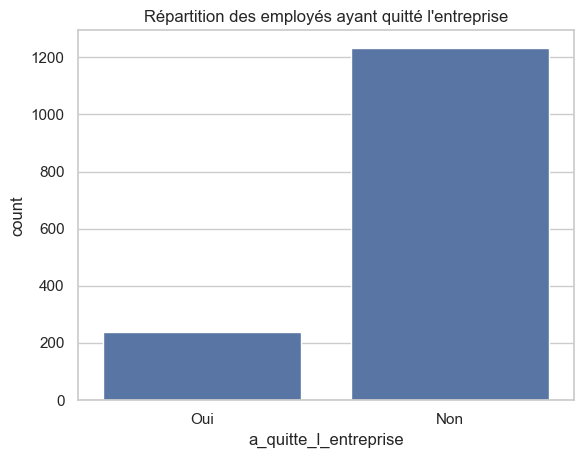

In [51]:
sns.countplot (data=df_central, x="a_quitte_l_entreprise")
plt.title ("Répartition des employés ayant quitté l'entreprise")
plt.show ( )

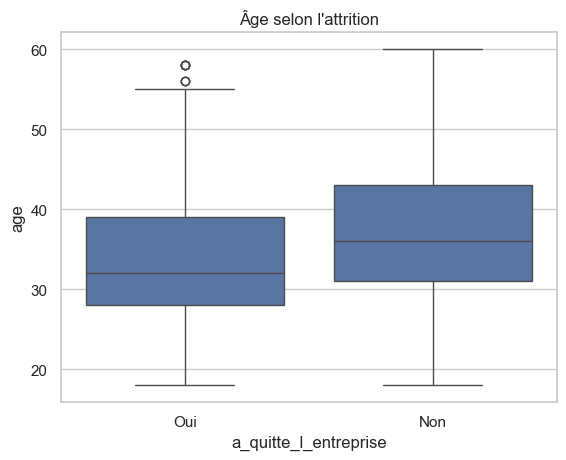

In [52]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="age")
plt.title ("Âge selon l'attrition")
plt.show ( )

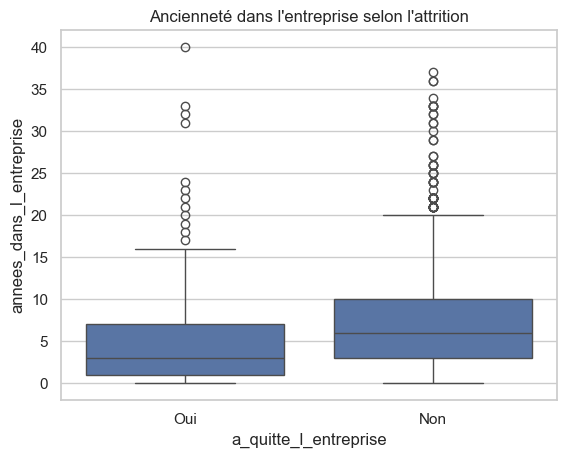

In [53]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="annees_dans_l_entreprise")
plt.title ("Ancienneté dans l'entreprise selon l'attrition")
plt.show ( )

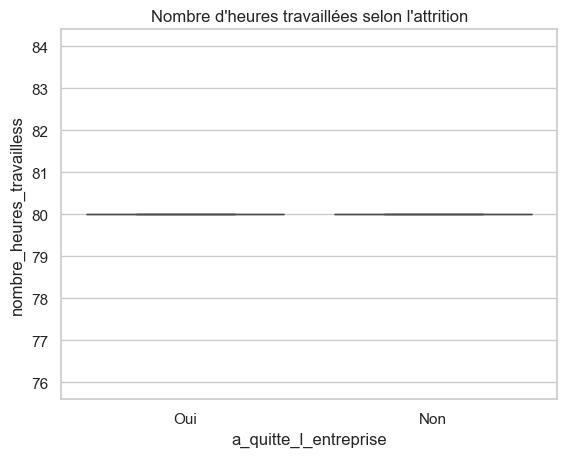

In [54]:
sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y="nombre_heures_travailless")
plt.title ("Nombre d'heures travaillées selon l'attrition")
plt.show ( )

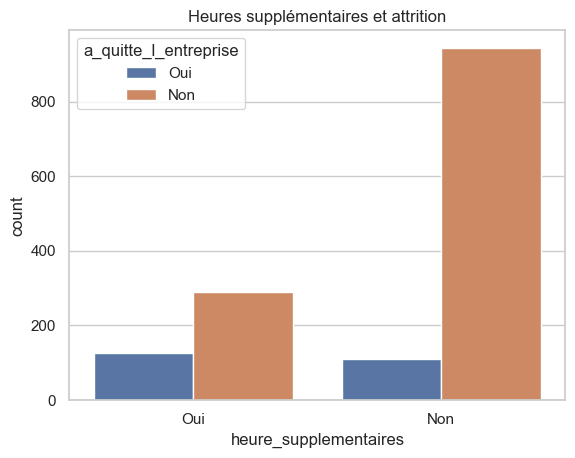

In [55]:
if "heure_supplementaires" in df_central.columns:
    sns.countplot (data=df_central, x="heure_supplementaires", hue="a_quitte_l_entreprise")
    plt.title ("Heures supplémentaires et attrition")
    plt.show ( )

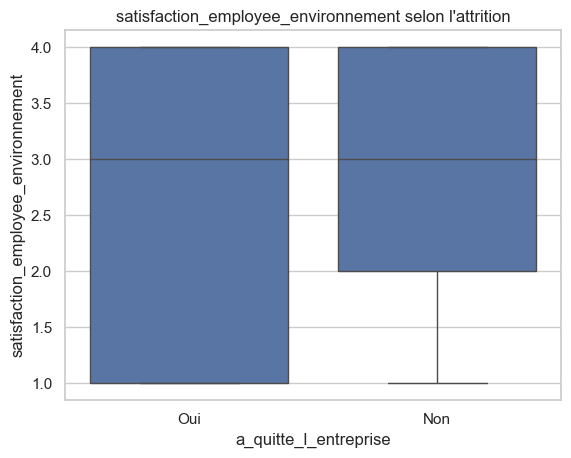

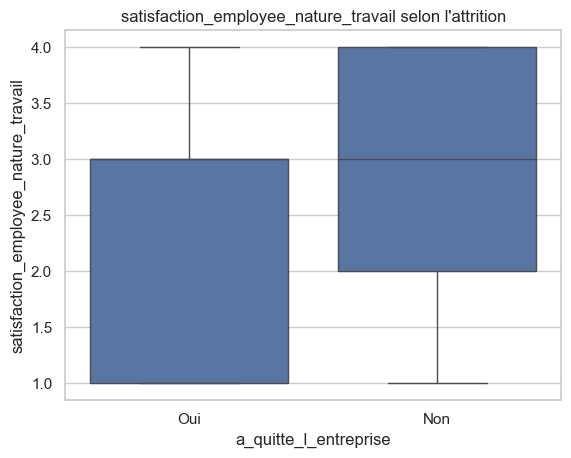

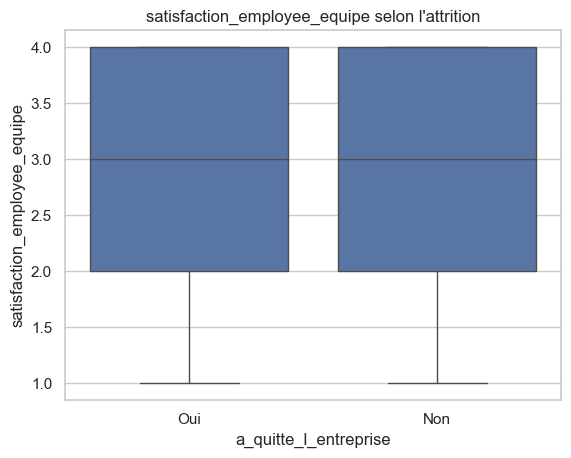

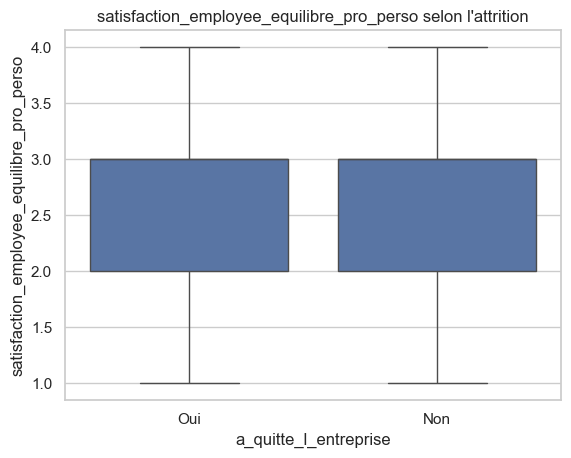

In [56]:
satisfaction_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

for col in satisfaction_cols:
    if col in df_central.columns:
        sns.boxplot (data=df_central, x="a_quitte_l_entreprise", y=col)
        plt.title (f"{col} selon l'attrition")
        plt.show ( )

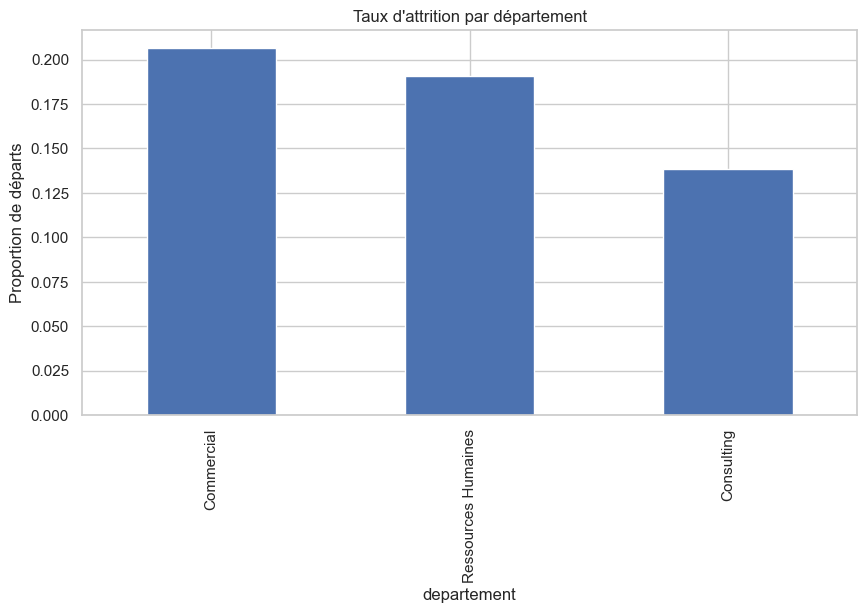

In [57]:
attrition_by_dep = pd.crosstab (
    df_central["departement"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
)

if "Oui" in attrition_by_dep.columns:
    attrition_by_dep["Oui"].sort_values (ascending=False).plot (kind="bar", figsize=(10, 5))
    plt.title ("Taux d'attrition par département")
    plt.ylabel ("Proportion de départs")
    plt.show ( )

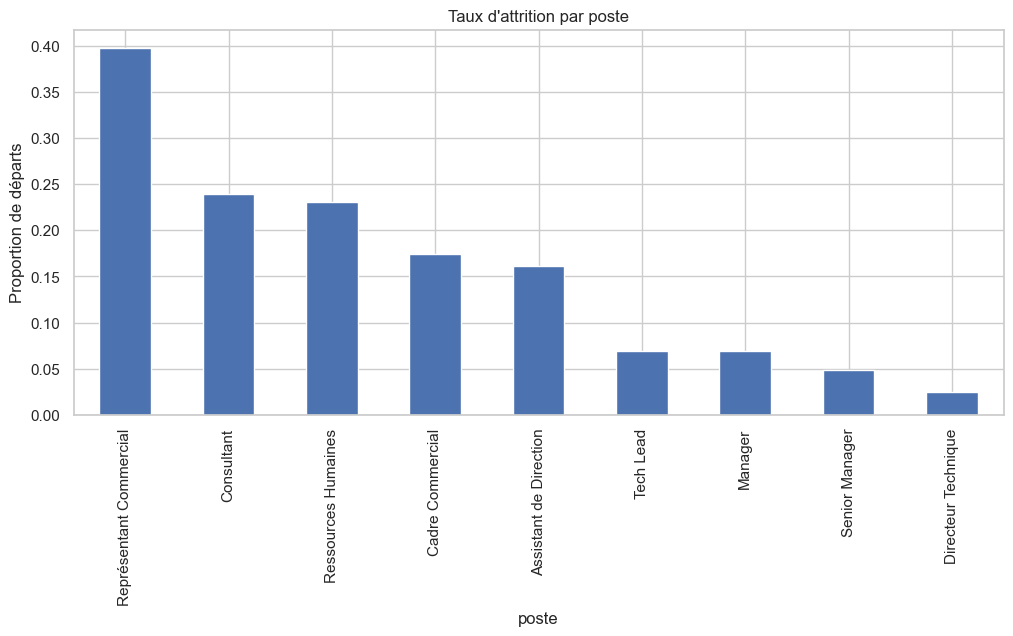

In [58]:
attrition_by_poste = pd.crosstab (
    df_central["poste"],
    df_central["a_quitte_l_entreprise"],
    normalize="index"
)

if "Oui" in attrition_by_poste.columns:
    attrition_by_poste["Oui"].sort_values (ascending=False).plot (kind="bar", figsize=(12, 5))
    plt.title ("Taux d'attrition par poste")
    plt.ylabel ("Proportion de départs")
    plt.show ( )

## 16. Corrélations entre variables numériques

Une matrice de corrélation est calculée pour mieux comprendre les relations linéaires entre les variables numériques.

Une attention particulière est portée à la corrélation avec la variable cible binaire `attrition_bin`, ce qui permet de repérer les variables potentiellement les plus liées au départ d’un employé.

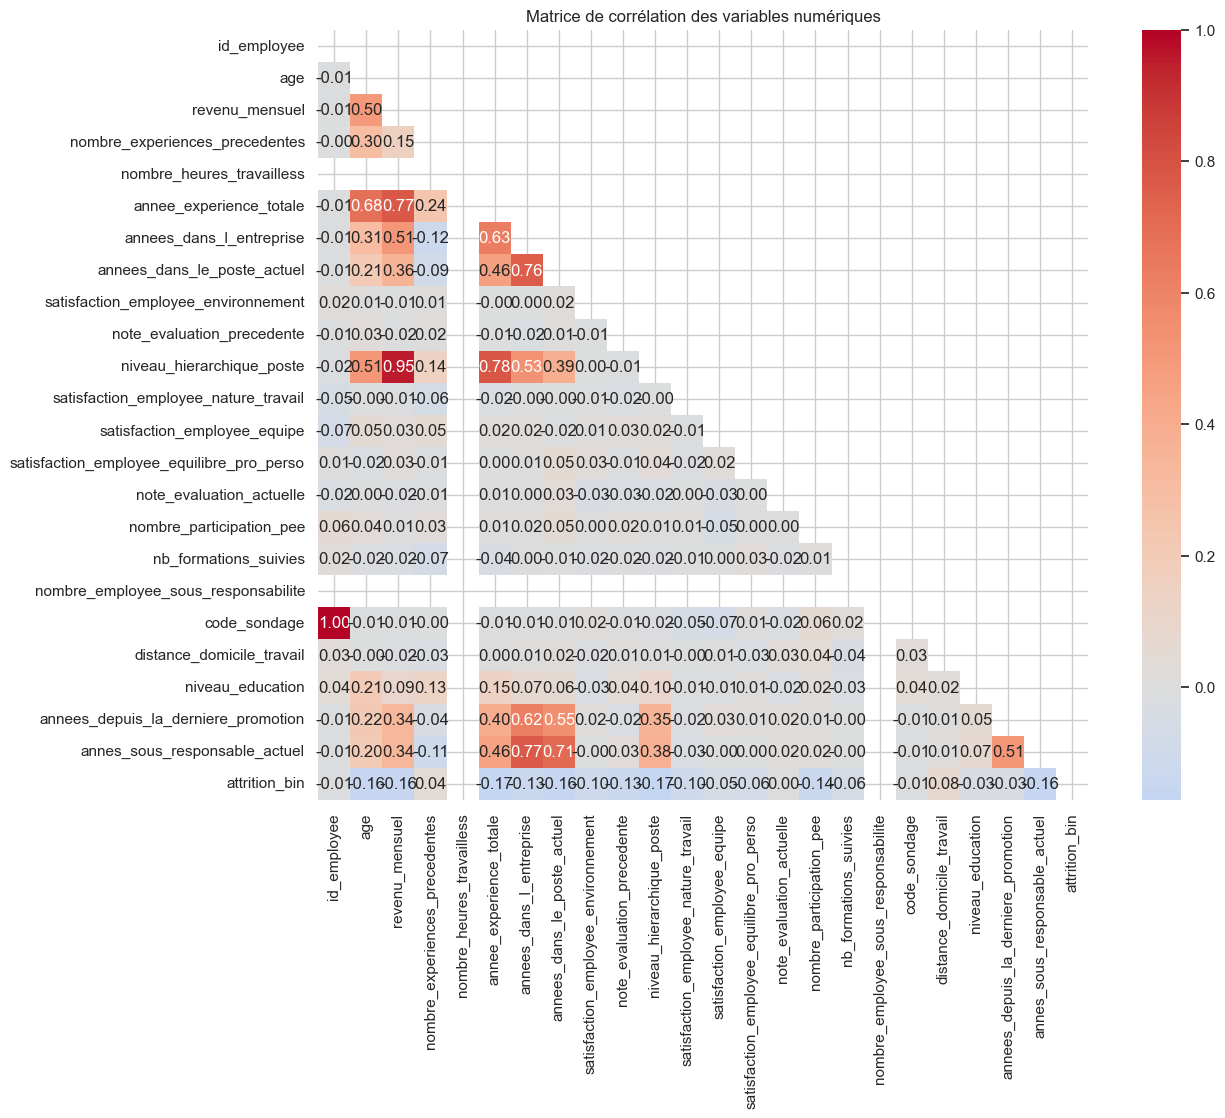

In [59]:
import numpy as np

plt.figure (figsize=(14, 10))
corr = df_central[num_cols].corr (numeric_only=True)
mask = np.triu (np.ones_like (corr, dtype=bool))

sns.heatmap (
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title ("Matrice de corrélation des variables numériques")
plt.show ( )

## 17. Synthèse intermédiaire

À ce stade de l’analyse exploratoire :

- les trois fichiers ont été chargés et inspectés ;
- un DataFrame central a été construit ;
- la variable cible a été identifiée et encodée ;
- des statistiques descriptives et des visualisations ont été produites.

Les premiers résultats suggèrent que certaines variables, comme l’ancienneté, le revenu mensuel, le niveau hiérarchique, l’expérience totale ou certains indicateurs de satisfaction, semblent associées à l’attrition.

Ces constats restent exploratoires et devront être confirmés dans la phase de modélisation supervisée.

In [60]:
cols_for_corr = [col for col in num_cols if col != "attrition_bin"] + ["attrition_bin"]

corr_target = (
    df_central[cols_for_corr]
    .corr (numeric_only=True)["attrition_bin"]
    .sort_values (ascending=False)
)

display (corr_target)

attrition_bin                                1.000000
distance_domicile_travail                    0.077924
nombre_experiences_precedentes               0.043494
note_evaluation_actuelle                     0.002889
code_sondage                                -0.010577
id_employee                                 -0.010577
niveau_education                            -0.031373
annees_depuis_la_derniere_promotion         -0.033019
satisfaction_employee_equipe                -0.045872
nb_formations_suivies                       -0.059478
satisfaction_employee_equilibre_pro_perso   -0.063939
satisfaction_employee_environnement         -0.103369
satisfaction_employee_nature_travail        -0.103481
note_evaluation_precedente                  -0.130016
annees_dans_l_entreprise                    -0.134392
nombre_participation_pee                    -0.137145
annes_sous_responsable_actuel               -0.156199
age                                         -0.159205
revenu_mensuel              

In [61]:
display (corr_target.drop ("attrition_bin"))

distance_domicile_travail                    0.077924
nombre_experiences_precedentes               0.043494
note_evaluation_actuelle                     0.002889
code_sondage                                -0.010577
id_employee                                 -0.010577
niveau_education                            -0.031373
annees_depuis_la_derniere_promotion         -0.033019
satisfaction_employee_equipe                -0.045872
nb_formations_suivies                       -0.059478
satisfaction_employee_equilibre_pro_perso   -0.063939
satisfaction_employee_environnement         -0.103369
satisfaction_employee_nature_travail        -0.103481
note_evaluation_precedente                  -0.130016
annees_dans_l_entreprise                    -0.134392
nombre_participation_pee                    -0.137145
annes_sous_responsable_actuel               -0.156199
age                                         -0.159205
revenu_mensuel                              -0.159840
annees_dans_le_poste_actuel 

~~~~~~~~## Conclusion

Cette première étape a permis de structurer les données RH issues de plusieurs sources et de mettre en évidence des différences entre les employés ayant quitté l’entreprise et ceux qui y sont encore.

L’analyse exploratoire constitue une base solide pour :

- la préparation des variables ;
- la construction d’un modèle de classification ;
- l’interprétation future des facteurs explicatifs de l’attrition.

La prochaine étape consistera à préparer les données pour la modélisation, entraîner plusieurs algorithmes de classification et comparer leurs performances.

### Lecture des corrélations avec la cible

Les corrélations observées avec `attrition_bin` restent globalement modérées, ce qui est cohérent dans un problème RH de ce type.

Plusieurs variables présentent une corrélation négative avec l’attrition, notamment :

- l’expérience totale ;
- le niveau hiérarchique du poste ;
- le revenu mensuel ;
- l’âge ;
- l’ancienneté dans l’entreprise et dans le poste actuel.

Cela suggère que les employés les plus expérimentés, les mieux rémunérés ou les plus installés dans l’organisation semblent moins susceptibles de quitter l’entreprise.

À l’inverse, `distance_domicile_travail` présente une corrélation positive, certes faible, mais allant dans le sens d’un risque de départ légèrement plus élevé lorsque la distance domicile-travail augmente.

Ces résultats doivent rester interprétés avec prudence : ils mettent en évidence des associations statistiques, mais ne constituent pas à eux seuls des relations causales.

In [62]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir (parents=True, exist_ok=True)

df_central.to_csv (DATA_PROCESSED / "df_central.csv", index=False)

print ("Fichier sauvegardé :", DATA_PROCESSED / "df_central.csv")

Fichier sauvegardé : /Users/vincentdesmouceaux/P4_Classifiez_automatiquement_des_informations/data/processed/df_central.csv


## Sauvegarde du DataFrame central

Le DataFrame central final est sauvegardé dans le dossier `data/processed` afin d’être réutilisé dans les étapes suivantes du projet, notamment pour la préparation des données et la modélisation.